# Regression Analysis

This notebook implements a complete preprocessing and modeling pipeline for predicting ISUP grades from radiomic features. It evaluates several regression models on a balanced feature set.

## Steps 

### 1. Data Loading and Merging
Radiomic features and clinical labels are merged using `study_id`, producing a unified dataset containing predictors and ISUP grades.

### 2. Class‑0 Undersampling via Nearest Neighbors
To reduce the dominance of ISUP class 0, each minority‑class sample (1–5) is paired with its nearest class‑0 neighbor.  
Only these selected class‑0 samples are retained, producing a more balanced dataset before oversampling.

### 3. SMOTE 
SMOTE is applied **only** to classes 3, 4, and 5, increasing each to 150 samples while leaving classes 0–2 unchanged.  

### 4. Regression Modeling
Three regression approaches are evaluated:
- Standard Linear Regression  
- Linear Regression with ANOVA feature selection  
- Lasso Regression with cross‑validated regularization  

All models use standardized predictors and targets.

### 5. Evaluation and Feature Analysis
Model performance is assessed using MSE and R².  
Spearman correlations are computed to identify radiomic features most associated with ISUP grade.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE 


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# Load your data again
features = pd.read_csv('../features.csv')
targets = pd.read_csv('../targets.csv')

data = features.merge(targets[['study_id','patient_id','case_ISUP']], on='study_id')

# Define predictors and target
X = data.drop(['study_id','case_ISUP'], axis=1)
y = data['case_ISUP']


In [3]:
df = X.copy() 
df["case_ISUP"] = y

idx_class0 = df.index[df["case_ISUP"] == 0]

# Storage for selected class-0 samples 
selected_class0 = []

# For each class 1–5, find nearest class-0 sample

for cls in range(1, 6): 
    print(f"Processing class {cls}") 
    idx_cls = df.index[df["case_ISUP"] == cls] 
    
    # Fit KNN on class 0 samples 
    knn = NearestNeighbors(n_neighbors=1) 
    knn.fit(df.loc[idx_class0, X.columns]) 
    
    # For each sample in class cls, find nearest class-0 sample 
    distances, indices = knn.kneighbors(df.loc[idx_cls, X.columns]) 
    # Convert neighbor indices to original dataframe indices 
    nearest_idx0 = idx_class0[indices.flatten()] 
    # Add to list 
    selected_class0.extend(nearest_idx0)

# keep only unique samples in class 0
selected_class0 = list(set(selected_class0)) 
print(f"\nOriginal class 0 count: {len(idx_class0)}") 
print(f"New class 0 count: {len(selected_class0)}")

# new reduced dataset
df_new = pd.concat([ df[df["case_ISUP"] != 0], # keep all minority classes 
                    df.loc[selected_class0] # keep only selected class-0 samples ])
])

print("\nFinal class counts:")
print(df_new["case_ISUP"].value_counts().sort_index())



# SMOTE only for classes 3, 4, 5

X_smote = df_new.drop(columns=["case_ISUP"])
y_smote = df_new["case_ISUP"]

sampling_strategy = {
    3: 150,
    4: 150,
    5: 150
}

sm = SMOTE(
    sampling_strategy=sampling_strategy,
    k_neighbors=3,
    random_state=42
)

X_resampled, y_resampled = sm.fit_resample(X_smote, y_smote)

df_resampled = pd.concat([
    pd.DataFrame(X_resampled, columns=X_smote.columns),
    pd.Series(y_resampled, name="case_ISUP")
], axis=1)

print("\nFinal class counts AFTER SMOTE:")
print(df_resampled["case_ISUP"].value_counts().sort_index())


Processing class 1
Processing class 2
Processing class 3
Processing class 4
Processing class 5

Original class 0 count: 589
New class 0 count: 262

Final class counts:
case_ISUP
0    262
1    157
2    154
3     69
4     27
5     35
Name: count, dtype: int64

Final class counts AFTER SMOTE:
case_ISUP
0    262
1    157
2    154
3    150
4    150
5    150
Name: count, dtype: int64


In [4]:

X_balanced = df_new.drop(columns=["case_ISUP"]) 
y_balanced = df_new["case_ISUP"]

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)


In [5]:
# Scale predictors 
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)


# Scale target 
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()


In [6]:
# Fit Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MSE: 2.7729506629816143
R²: -0.3581255451994845


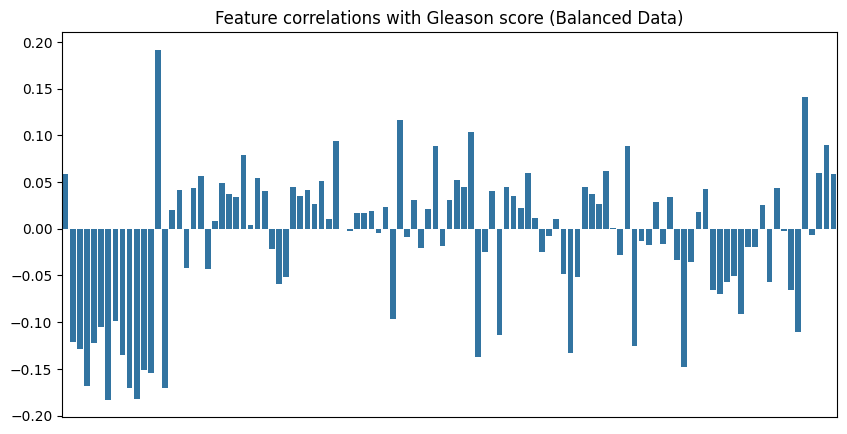

In [7]:
# Spearman correlation
corrs = X_balanced.corrwith(y_balanced, method='spearman')

plt.figure(figsize=(10,5))
sns.barplot(x=corrs.index, y=corrs.values)
plt.xticks([])
plt.xlabel("")
plt.title("Feature correlations with Gleason score (Balanced Data)")
plt.show()


In [8]:
## Linear Regression with ANOVA-selected features

selector = SelectKBest(score_func=f_regression, k=10)
X_selected = selector.fit_transform(X_balanced, y_balanced)
selected_features = X_balanced.columns[selector.get_support()]
print("Selected features (ANOVA):", selected_features.tolist())

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_balanced[selected_features], y_balanced, test_size=0.2, random_state=42
)

scaler_X_sel = StandardScaler()
X_train_sel_scaled = scaler_X_sel.fit_transform(X_train_sel)
X_test_sel_scaled  = scaler_X_sel.transform(X_test_sel)

scaler_y_sel = StandardScaler()
y_train_sel_scaled = scaler_y_sel.fit_transform(y_train_sel.values.reshape(-1,1)).ravel()
y_test_sel_scaled  = scaler_y_sel.transform(y_test_sel.values.reshape(-1,1)).ravel()

# Fit Linear Regression
lr = LinearRegression()
lr.fit(X_train_sel_scaled, y_train_sel_scaled)
y_pred_sel_scaled = lr.predict(X_test_sel_scaled)
y_pred_sel = scaler_y_sel.inverse_transform(y_pred_sel_scaled.reshape(-1,1)).ravel()

print("\n--- Linear Regression (ANOVA-selected features, balanced) ---")
print("MSE:", mean_squared_error(y_test_sel, y_pred_sel))
print("R²:", r2_score(y_test_sel, y_pred_sel))


Selected features (ANOVA): ['original_shape_LeastAxisLength', 'original_shape_Maximum2DDiameterRow', 'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume', 'original_shape_MinorAxisLength', 'original_shape_Sphericity', 'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio', 'original_shape_VoxelVolume', 'original_glszm_GrayLevelNonUniformity']

--- Linear Regression (ANOVA-selected features, balanced) ---
MSE: 2.2660278911915324
R²: -0.10984678027145378


In [9]:
## Lasso Regression 

X_train_lasso, X_test_lasso, y_train_lasso, y_test_lasso = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

scaler_lasso = StandardScaler()
X_train_lasso_scaled = scaler_lasso.fit_transform(X_train_lasso)
X_test_lasso_scaled  = scaler_lasso.transform(X_test_lasso)

# Fit Lasso
lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=50000,
    tol=1e-4,
    alphas=np.logspace(-3, 1, 50)
).fit(X_train_lasso_scaled, y_train_lasso)

y_pred_lasso = lasso.predict(X_test_lasso_scaled)

print("\n--- Lasso Regression ---")
print("MSE:", mean_squared_error(y_test_lasso, y_pred_lasso))
print("R²:", r2_score(y_test_lasso, y_pred_lasso))
print("Number of selected features:", np.sum(lasso.coef_ != 0))

selected_by_lasso = X_balanced.columns[lasso.coef_ != 0]
print("Selected features:", selected_by_lasso.tolist())



--- Lasso Regression ---
MSE: 2.4149213898829984
R²: -0.18277128873334392
Number of selected features: 25
Selected features: ['patient_id_x', 'original_shape_Elongation', 'original_shape_Flatness', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn', 'original_shape_Maximum2DDiameterRow', 'original_shape_Sphericity', 'original_firstorder_Kurtosis', 'original_firstorder_Minimum', 'original_firstorder_Range', 'original_glcm_ClusterTendency', 'original_glcm_Idmn', 'original_glcm_Imc1', 'original_glcm_Imc2', 'original_glcm_MCC', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_glrlm_RunEntropy', 'original_glrlm_RunLengthNonUniformity', 'original_glrlm_RunLengthNonUniformityNormalized', 'original_glrlm_ShortRunEmphasis', 'original_glszm_GrayLevelNonUniformity', 'original_glszm_LargeAreaLowGrayLevelEmphasis', 'original_glszm_SmallAreaEmphasis', 'original_glszm_SmallAreaLowGrayLevelEmphasis', 'original_ngtdm_Coarseness']
